In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

I0000 00:00:1778266751.744965   19743 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778266751.747300   19743 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778266752.097655   19743 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778266753.498893   19743 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# Load dataset
df = pd.read_csv("boston_house_prices.csv")

In [3]:
# Display dataset
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


In [4]:
# Separate features and target
X = df.drop(columns=['PRICE'])   # Target column is MEDV (price)
y = df['PRICE']


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
# Feature scaling (VERY IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Build Deep Neural Network
model = Sequential()

In [9]:
# Input + Hidden Layers
model.add(Dense(64, activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))


In [10]:
# Output Layer (Linear regression → no activation)
model.add(Dense(1))


In [11]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)


In [12]:
# Train model
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 202.1402 - mae: 11.0819 - val_loss: 87.9790 - val_mae: 6.8233
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.7803 - mae: 4.2175 - val_loss: 34.8084 - val_mae: 3.6602
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.5122 - mae: 3.2309 - val_loss: 28.0249 - val_mae: 3.3179
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.6970 - mae: 2.7564 - val_loss: 28.2989 - val_mae: 3.2672
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.5171 - mae: 2.5733 - val_loss: 26.3336 - val_mae: 3.4526
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.7219 - mae: 2.3537 - val_loss: 22.0093 - val_mae: 3.0079
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.7607 - mae: 2.3298 - val_loss: 16.1499 - val_mae: 2.7544
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.0148 - mae: 2.1856 - val_loss: 16.2589 - val_mae: 2.8840
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

In [13]:
# Evaluate model
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.9074 - mae: 2.4678
Test Loss (MSE): 11.907408714294434
Test MAE: 2.467841148376465


In [14]:
# Predictions
y_pred = model.predict(X_test)



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [15]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

In [16]:
print(comparison.head())

   Actual  Predicted
0    23.6  26.532772
1    32.4  35.070034
2    13.6  17.920956
3    22.8  23.687855
4    16.1  18.418476


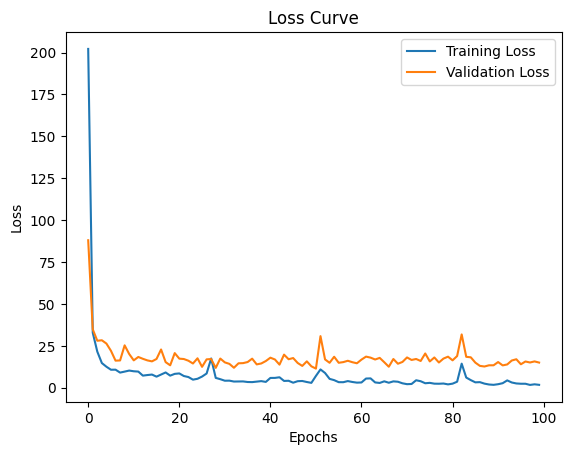

In [18]:
#optional chart
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
